In [ ]:
# %% [markdown]
# # ResNet Training Strategy 2: Progressive Dataset Revelation - V2 [PyTorch]
#
# CIFAR-10: 60,000 32x32 colour images in 10 classes
# - 50,000 training images | 10,000 test images
# - Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
#
# **Strategy**: Progressive dataset revelation.
#
# Train the final ResNet in stages by gradually increasing how much of the
# training set is visible:
# - Stage 1: 10% of data
# - Stage 2: 25% of data
# - Stage 3: 50% of data
# - Stage 4: 75% of data
# - Stage 5: 100% of data
#
# **Hyperparameters kept from curriculum setup:**
# - Learning rate: 0.001
# - Epochs per stage: 5
# - Batch size: 128
# - ReduceLROnPlateau scheduler (patience=3, factor=0.5)
#
# **PyTorch port**: Uses PyTorch + torchvision ResNet50 with CUDA GPU acceleration (RTX 3060).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

In [2]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Using device: cuda


In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
# ## Part 1 - Loading CIFAR-10 Data
# Download CIFAR-10 (raw, no transforms yet — we need raw data for scoring)
raw_trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True, download=True)
raw_testset = torchvision.datasets.CIFAR10(root='./dataset', train=False, download=True)

# Extract raw numpy arrays
x_train_raw = np.array(raw_trainset.data)       # (50000, 32, 32, 3) uint8
y_train_raw = np.array(raw_trainset.targets)     # (50000,)
x_test_raw = np.array(raw_testset.data)
y_test_raw = np.array(raw_testset.targets)

print(f"Train: {x_train_raw.shape}, Test: {x_test_raw.shape}")

100%|██████████| 170M/170M [00:04<00:00, 34.4MB/s]


Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [5]:
# Transforms: Training with augmentation, Test without
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=12, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [6]:
# Custom dataset class that works with numpy arrays + transforms
class CIFAR10Numpy(torch.utils.data.Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images   # uint8 numpy (N, 32, 32, 3)
        self.labels = labels   # int numpy (N,)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]          # (32, 32, 3) uint8
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        return img, label



In [7]:

# Test dataloader (no augmentation)
test_dataset = CIFAR10Numpy(x_test_raw, y_test_raw, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

In [8]:
# ## Part 2 - Building the ResNet
#
# We use torchvision's ResNet50 with `weights=None` (train from scratch) and adapt the
# first conv layer and final FC layer for CIFAR-10's 32×32 images and 10 classes.

# %%
def build_resnet():
    """Build a ResNet50 adapted for CIFAR-10 (32x32 input, 10 classes)."""
    model = models.resnet50(weights=None)

    # Replace first conv: original uses 7x7 stride 2 (for ImageNet 224x224).
    # For 32x32 CIFAR, use 3x3 stride 1, no maxpool, to preserve spatial dims.
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # Remove maxpool for small images

    # Replace final FC: 2048 → 256 → 10 (matching the TF version's head)
    model.fc = nn.Sequential(
        nn.Flatten(),
        nn.BatchNorm1d(2048),
        nn.Linear(2048, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 10)
    )
    return model

# %%
# Quick sanity check
_test_model = build_resnet().to(device)
_test_input = torch.randn(2, 3, 32, 32).to(device)
_test_output = _test_model(_test_input)
print(f"Model output shape: {_test_output.shape}")  # Should be [2, 10]
del _test_model, _test_input, _test_output
torch.cuda.empty_cache()


Model output shape: torch.Size([2, 10])


In [9]:
# ## Part 3 - Scoring Samples by Difficulty
#
# A lightly trained scorer model estimates per-sample loss so the training data
# can be ordered from easy to hard.
#
# **V2 Change:** Scorer now trains for 5 epochs (was 3) with learning rate 0.001
# (was 0.0001) for better difficulty estimation.

# %%
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


In [10]:

# %%
print("Building scorer model to assess sample difficulty...")
scorer = build_resnet().to(device)
scorer_optimizer = optim.Adam(scorer.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

scorer_train_dataset = CIFAR10Numpy(x_train_raw, y_train_raw, transform=train_transform)
scorer_train_loader = DataLoader(scorer_train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)

for epoch in range(5):
    train_loss, train_acc = train_one_epoch(scorer, scorer_train_loader, criterion, scorer_optimizer, device)
    print(f"  Scorer Epoch {epoch+1}/5 - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")

print("\nScorer training complete.")

# %%
print("Computing per-sample difficulty scores...")

# Use non-augmented data for consistent scoring
score_dataset = CIFAR10Numpy(x_train_raw, y_train_raw, transform=test_transform)
score_loader = DataLoader(score_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

scorer.eval()
all_losses = []
with torch.no_grad():
    for images, labels in score_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = scorer(images)
        # Per-sample cross-entropy loss
        loss_per_sample = nn.functional.cross_entropy(outputs, labels, reduction='none')
        all_losses.append(loss_per_sample.cpu().numpy())

per_sample_loss = np.concatenate(all_losses)

print(f"\nDifficulty score statistics:")
print(f"  Min loss (easiest):  {per_sample_loss.min():.4f}")
print(f"  Max loss (hardest):  {per_sample_loss.max():.4f}")
print(f"  Mean loss:           {per_sample_loss.mean():.4f}")
print(f"  Median loss:         {np.median(per_sample_loss):.4f}")

# Free scorer memory
del scorer, scorer_optimizer, scorer_train_loader, score_loader
torch.cuda.empty_cache()

# %%
difficulty_order = np.argsort(per_sample_loss)

x_train_sorted = x_train_raw[difficulty_order]
y_train_sorted = y_train_raw[difficulty_order]
loss_sorted = per_sample_loss[difficulty_order]

print("Training data sorted by difficulty (easy → hard).")
print(f"  Easiest 5 losses: {loss_sorted[:5]}")
print(f"  Hardest 5 losses: {loss_sorted[-5:]}")


Building scorer model to assess sample difficulty...


KeyboardInterrupt: 

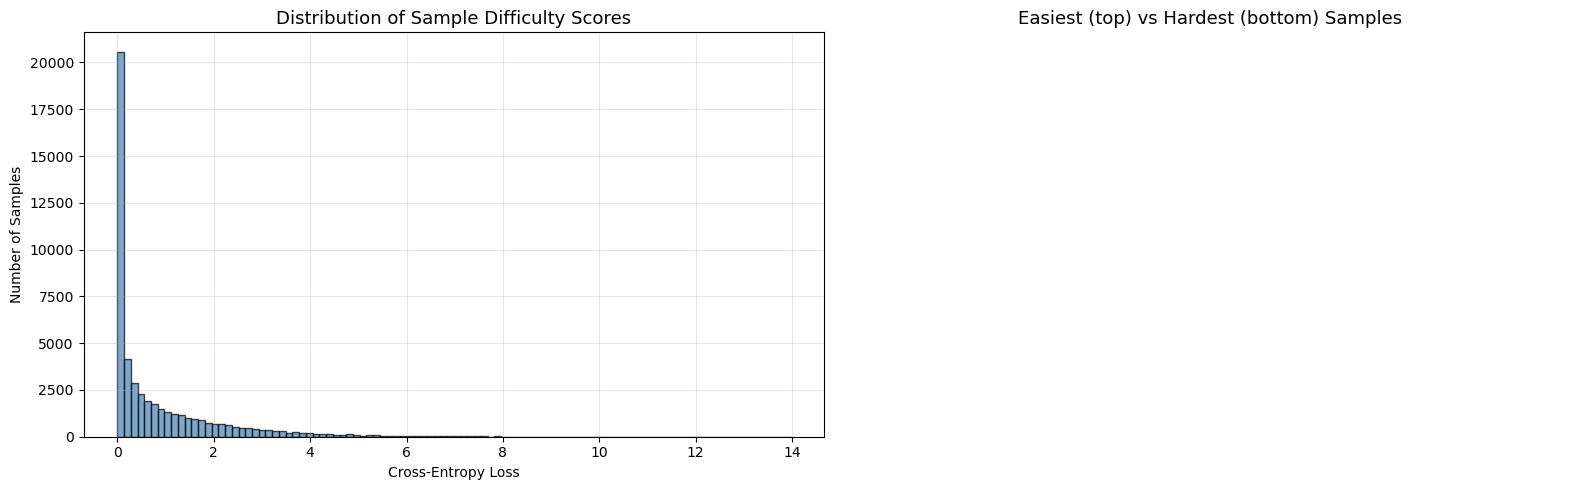

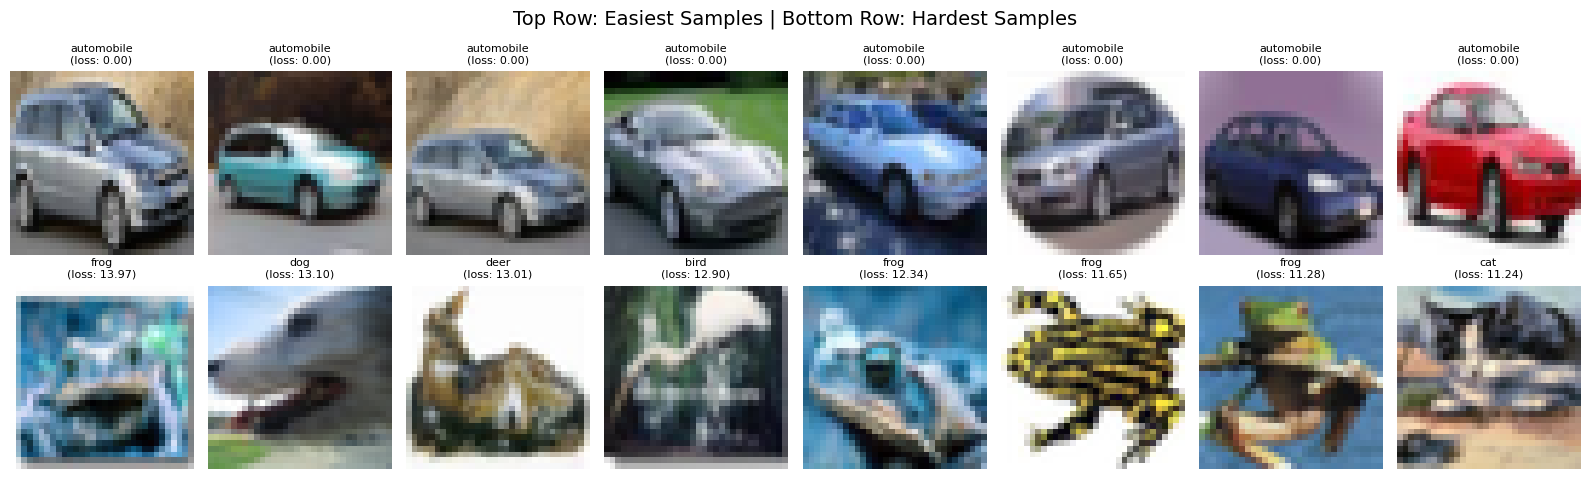

In [ ]:

# %% [markdown]
# ### Visualize the difficulty distribution

# %%
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_sample_loss, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Sample Difficulty Scores', fontsize=13)
axes[0].set_xlabel('Cross-Entropy Loss')
axes[0].set_ylabel('Number of Samples')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Easiest (top) vs Hardest (bottom) Samples', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Top Row: Easiest Samples | Bottom Row: Hardest Samples', fontsize=14)

for i in range(8):
    axes[0, i].imshow(x_train_sorted[i])
    true_label = int(y_train_sorted[i])
    axes[0, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[i]:.2f})', fontsize=8)
    axes[0, i].axis('off')

    idx = -(i + 1)
    axes[1, i].imshow(x_train_sorted[idx])
    true_label = int(y_train_sorted[idx])
    axes[1, i].set_title(f'{class_names[true_label]}\n(loss: {loss_sorted[idx]:.2f})', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [12]:

# %% [markdown]
# ## Part 4 - Progressive Training
#
# Now we train a fresh model using progressive data revelation.
#
# **Hyperparameters (kept from curriculum setup):**
# - Learning rate: 0.001
# - Epochs per stage: 5
# - Batch size: 128
# - ReduceLROnPlateau callback (patience=3, factor=0.5)

# %%
# Progressive revelation schedule: fraction of data to use at each stage
progressive_fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
epochs_per_stage = 5

# Shuffle once so each stage is a larger prefix of the same random ordering
progressive_order = np.random.permutation(len(x_train_raw))
x_train_progressive = x_train_raw[progressive_order]
y_train_progressive = y_train_raw[progressive_order]

print("Progressive Dataset Revelation Schedule:")
print("=" * 60)
for i, frac in enumerate(progressive_fractions):
    n_samples = int(len(x_train_progressive) * frac)
    print(f"Stage {i + 1}: {frac*100:.0f}% → {n_samples:,} samples ({epochs_per_stage} epochs)")
print(f"\nTotal epochs: {len(progressive_fractions) * epochs_per_stage}")

# %%
resnet_model = build_resnet().to(device)
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

# Print model parameter count
total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# %%
full_history = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': []
}

stage_boundaries = []

for stage_idx, fraction in enumerate(progressive_fractions):
    n_samples = int(len(x_train_progressive) * fraction)
    x_subset = x_train_progressive[:n_samples]
    y_subset = y_train_progressive[:n_samples]

    train_dataset = CIFAR10Numpy(x_subset, y_subset, transform=train_transform)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)

    print(f"\n{'='*70}")
    print(f"STAGE {stage_idx + 1}/{len(progressive_fractions)}: Training with {fraction*100:.0f}% data ({n_samples:,} samples)")
    print(f"{'='*70}")

    stage_boundaries.append(len(full_history['train_acc']))

    for epoch in range(epochs_per_stage):
        train_loss, train_acc = train_one_epoch(resnet_model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(resnet_model, test_loader, criterion, device)
        scheduler.step(val_loss)

        full_history['train_acc'].append(train_acc)
        full_history['val_acc'].append(val_acc)
        full_history['train_loss'].append(train_loss)
        full_history['val_loss'].append(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1}/{epochs_per_stage} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}")

    print(f"\nStage {stage_idx + 1} Complete:")
    print(f"  Train Accuracy: {full_history['train_acc'][-1]:.4f}")
    print(f"  Val Accuracy:   {full_history['val_acc'][-1]:.4f}")

print(f"\n{'='*70}")
print("Progressive training complete!")
print(f"{'='*70}")


Progressive Dataset Revelation Schedule:
Stage 1: 10% → 5,000 samples (5 epochs)
Stage 2: 25% → 12,500 samples (5 epochs)
Stage 3: 50% → 25,000 samples (5 epochs)
Stage 4: 75% → 37,500 samples (5 epochs)
Stage 5: 100% → 50,000 samples (5 epochs)

Total epochs: 25
Total parameters: 24,031,562
Trainable parameters: 24,031,562

STAGE 1/5: Training with 10% data (5,000 samples)
  Epoch 1/5 - Train Loss: 2.2733, Train Acc: 0.2024, Val Loss: 2.0306, Val Acc: 0.2656, LR: 0.001000
  Epoch 2/5 - Train Loss: 1.9969, Train Acc: 0.2838, Val Loss: 2.2080, Val Acc: 0.3433, LR: 0.001000
  Epoch 3/5 - Train Loss: 1.8586, Train Acc: 0.3454, Val Loss: 2.3019, Val Acc: 0.3339, LR: 0.001000
  Epoch 4/5 - Train Loss: 1.7266, Train Acc: 0.3784, Val Loss: 1.8647, Val Acc: 0.3831, LR: 0.001000
  Epoch 5/5 - Train Loss: 1.7472, Train Acc: 0.3834, Val Loss: 1.6200, Val Acc: 0.4335, LR: 0.001000

Stage 1 Complete:
  Train Accuracy: 0.3834
  Val Accuracy:   0.4335

STAGE 2/5: Training with 25% data (12,500 sample

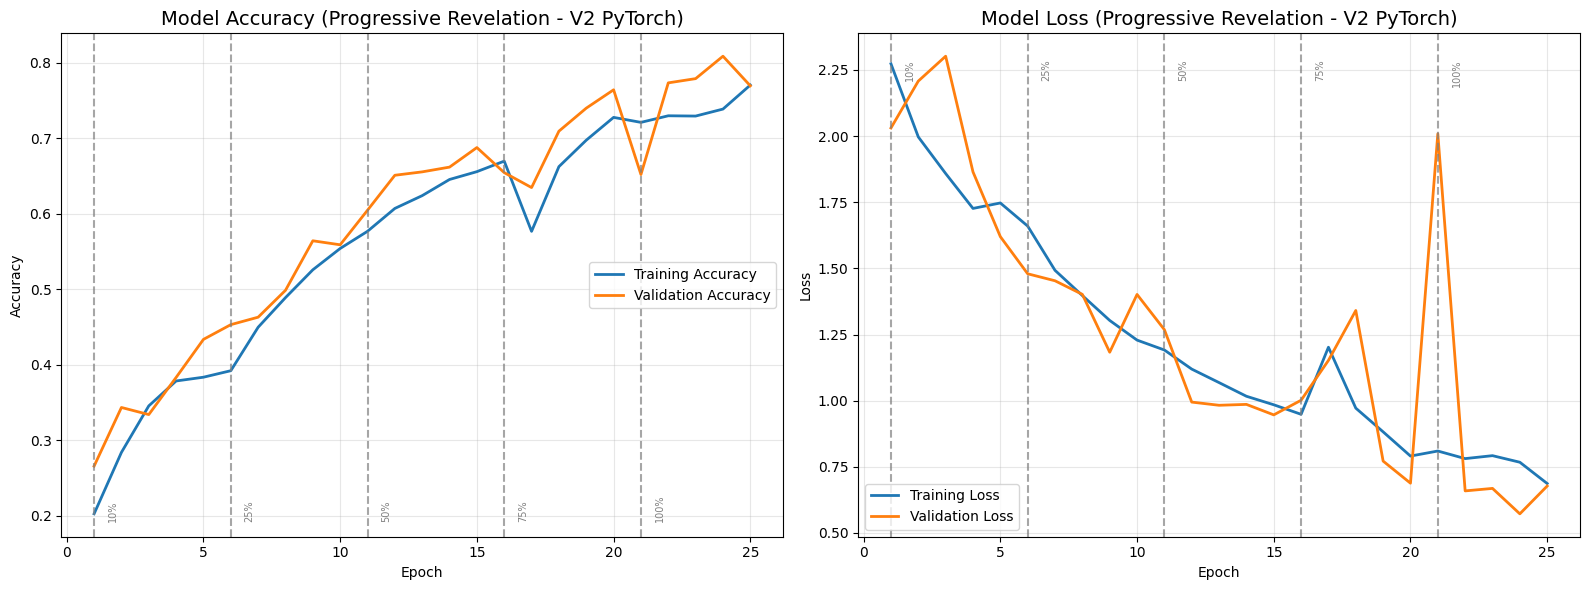


Test Loss     : 0.6773
Test Accuracy : 0.7694
Model saved to cifar10_resnet_progressive_v2_pytorch.pth
Predicted class : ship (100.0% confidence)
Actual class    : ship


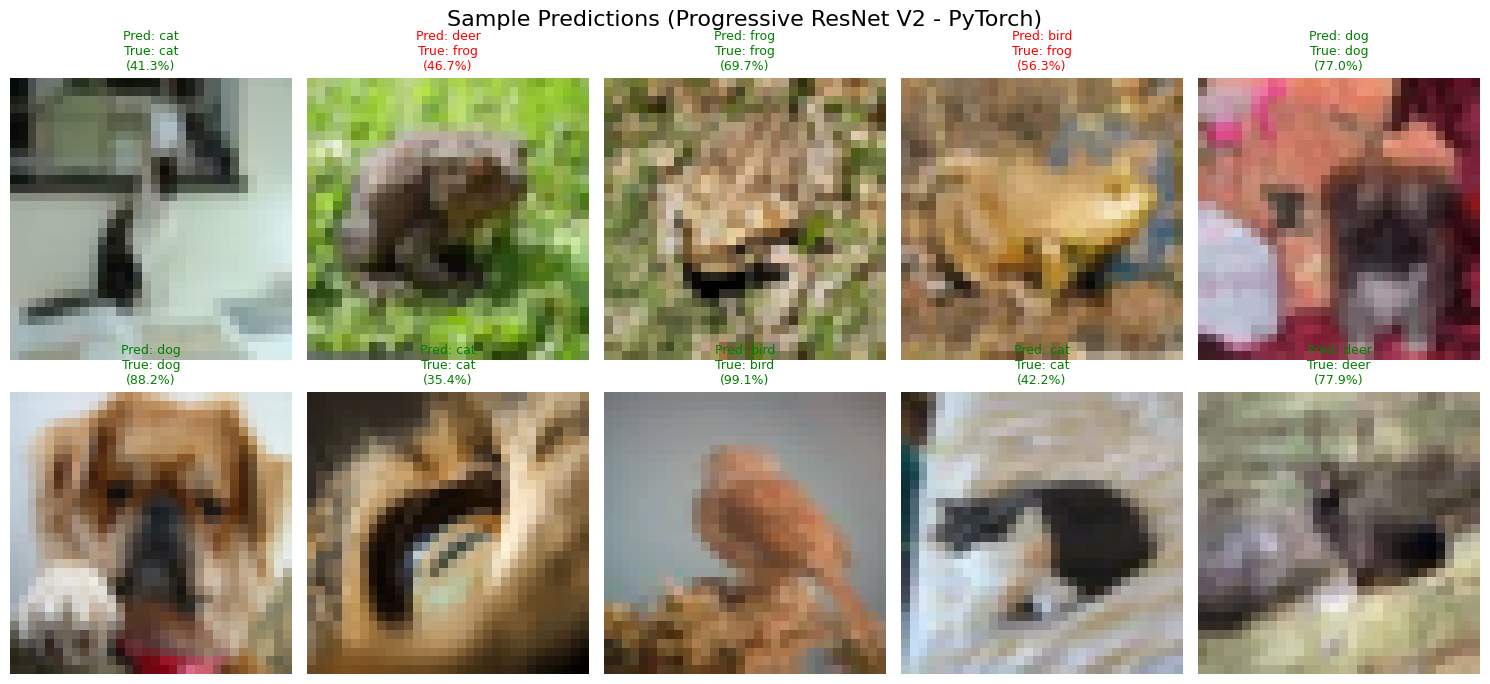

In [13]:
# %% [markdown]
# ## Part 5 - Evaluating the Results

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(full_history['train_acc']) + 1)

ax1.plot(epochs_range, full_history['train_acc'], label='Training Accuracy', linewidth=2)
ax1.plot(epochs_range, full_history['val_acc'], label='Validation Accuracy', linewidth=2)
for i, boundary in enumerate(stage_boundaries):
    frac = progressive_fractions[i]
    ax1.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax1.text(boundary + 1.5, ax1.get_ylim()[0] + 0.02, f'{frac*100:.0f}%',
             fontsize=7, color='gray', rotation=90, va='bottom')

ax1.set_title('Model Accuracy (Progressive Revelation - V2 PyTorch)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, full_history['train_loss'], label='Training Loss', linewidth=2)
ax2.plot(epochs_range, full_history['val_loss'], label='Validation Loss', linewidth=2)
for i, boundary in enumerate(stage_boundaries):
    frac = progressive_fractions[i]
    ax2.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax2.text(boundary + 1.5, ax2.get_ylim()[1] - 0.1, f'{frac*100:.0f}%',
             fontsize=7, color='gray', rotation=90, va='top')

ax2.set_title('Model Loss (Progressive Revelation - V2 PyTorch)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
test_loss, test_accuracy = evaluate(resnet_model, test_loader, criterion, device)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# %%
# Save model
torch.save(resnet_model.state_dict(), 'cifar10_resnet_progressive_v2_pytorch.pth')
print("Model saved to cifar10_resnet_progressive_v2_pytorch.pth")

# %% [markdown]
# ## Part 6 - Making a single prediction

# %%
idx = np.random.randint(0, len(x_test_raw))
test_image = x_test_raw[idx]

test_image_tensor = test_transform(test_image).unsqueeze(0).to(device)

resnet_model.eval()
with torch.no_grad():
    result = resnet_model(test_image_tensor)
    probabilities = torch.softmax(result, dim=1)
    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0][predicted_class].item() * 100
    actual_class = int(y_test_raw[idx])

print(f"Predicted class : {class_names[predicted_class]} ({confidence:.1f}% confidence)")
print(f"Actual class    : {class_names[actual_class]}")

# %%
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Sample Predictions (Progressive ResNet V2 - PyTorch)', fontsize=16)

resnet_model.eval()
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(x_test_raw))
    test_img = x_test_raw[idx]
    test_img_tensor = test_transform(test_img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = resnet_model(test_img_tensor)
        probs = torch.softmax(pred, dim=1)
        pred_cls = probs.argmax(dim=1).item()
        conf = probs[0][pred_cls].item() * 100
        actual_cls = int(y_test_raw[idx])

    ax.imshow(test_img)
    color = 'green' if pred_cls == actual_cls else 'red'
    ax.set_title(f'Pred: {class_names[pred_cls]}\nTrue: {class_names[actual_cls]}\n({conf:.1f}%)',
                 fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()
